# Árvores de Decisão: Classificação e Regressão

## 1. Introdução

A **Árvore de Decisão (Decision Tree)** é um dos algoritmos de **Machine Learning Supervisionado** mais intuitivos e poderosos, servindo de bloco fundamental para arquiteturas mais complexas (como Random Forest e Gradient Boosting).

Diferente do KNN (que é um algoritmo de aprendizado preguiçoso - *lazy learning*), a Árvore de Decisão é um modelo de **aprendizado ansioso (*eager learning*)**. Durante a fase de treinamento, o algoritmo constrói ativamente um modelo computacional na forma de um Grafo Acíclico Direcionado (DAG), induzindo regras de decisão a partir das *features*.

Trata-se de um modelo **não-paramétrico**, o que significa que ele não assume nenhuma distribuição de probabilidade subjacente aos dados e pode modelar relações altamente não-lineares dividindo o espaço de características em hiper-retângulos.

O algoritmo mais conhecido para Arvores de Decisão, o **CART** (Classification and Regression Trees), considera **árvores binárias**, isto é, **árvores em que os nós possuem no máximo 2 nós filhos**, e iremos considerar essa abordagem.

## 2. O problema que queremos resolver

Assim como o KNN, as Árvores de Decisão são versáteis e resolvem problemas de **Classificação** e **Regressão** (algoritmos conhecidos historicamente como CART - *Classification and Regression Trees*).

A lógica central é: **Qual é a melhor sequência de perguntas (testes em variáveis) que divide meus dados de forma a separar perfeitamente as classes ou prever o valor alvo com o menor erro possível?**

O espaço de busca por todas as árvores possíveis é NP-Completo. Por isso, a construção da árvore baseia-se em um algoritmo **guloso (*greedy*)**, realizando a melhor divisão local em cada nó, sem garantia de encontrar a árvore globalmente ótima.

## 3. O Algoritmo (Formalização e Estrutura)

Seja um conjunto de treinamento $D = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_n, y_n)\}$.

A estrutura gerada é composta por:
1. **Nó Raiz (Root Node)**: Representa toda a base de dados antes de qualquer divisão.
2. **Nós Internos (Internal Nodes)**: Representam uma condição de teste em um atributo $j$ (ex: $x_{ij} \leq threshold$).
3. **Ramos (Branches)**: Representam o resultado do teste (Verdadeiro ou Falso), direcionando o fluxo para os sub-nós.
4. **Nós Folha (Leaf Nodes)**: Nós terminais que não possuem filhos e contêm a predição final (a classe majoritária ou a média do alvo).

## 4. A Matemática da Construção da Arvore

Para construir a árvore, o algoritmo precisa decidir **onde** e **como** dividir os dados em cada nó. O objetivo é sempre criar nós filhos que sejam mais "puros" que o nó pai.

**O que é um nó puro?**
É um agrupamento onde (idealmente) todas as amostras pertencem à mesma classe.
- **Nó 100% impuro (Caos Máximo):** 50% das amostras são da Classe A e 50% da Classe B. É impossível tomar uma decisão com certeza, é como jogar uma moeda.
- **Nó 100% puro (Ordem Total):** 100% das amostras são da Classe A ou 100% das amostras são da Classe B. A decisão de classificação é óbvia.

Para medir e quantificar essa "impureza", usamos funções matemáticas. O algoritmo simula todas as divisões possíveis nas variáveis e escolhe aquela divisão que **minimiza a impureza** (ou seja, maximiza a pureza) após o corte.

### 4.1. Entropia (A Medida do Caos)

Emprestada da Teoria da Informação de Claude Shannon, a Entropia mede o nível de desorganização, incerteza ou "surpresa" de um conjunto de dados.

$$\Large H(S) = - \sum_{c=1}^{C} p_c \log_2(p_c)$$

Onde:
- $S$ é o conjunto de dados no nó atual.
- $C$ é o número total de classes.
- $p_c$ é a probabilidade (ou proporção) de um elemento pertencer à classe $c$ dentro desse nó.
- **Por que $\log_2$?** Na teoria da informação, medimos o ganho de conhecimento em *bits*. Um bit resolve a incerteza entre duas opções.

**Exemplo numérico (Problema Binário: Vai chover? Sim ou Não):**
Imagine um nó onde caíram 10 exemplos.

**Cenário A (Caos Total - 5 Sim, 5 Não):**
A proporção de "Sim" é 0.5 ($5/10$) e de "Não" é 0.5 ($5/10$).
Aplicando na fórmula:
$H(S) = - (0.5 \cdot \log_2(0.5) + 0.5 \cdot \log_2(0.5))$
$H(S) = - (-0.5 - 0.5) = 1.0$
> *Uma Entropia de 1.0 significa impureza máxima para problemas de duas classes. Estamos totalmente incertos.* 

**Cenário B (Pureza Total - 10 Sim, 0 Não):**
A proporção de "Sim" é 1.0 e de "Não" é 0.0.
$H(S) = - (1.0 \cdot \log_2(1.0) + 0) = - (1.0 \cdot 0) = 0.0$
> *Uma Entropia de 0.0 significa que o nó está perfeitamente organizado. Não há incerteza, todos os casos apontam para o mesmo resultado.*

### 4.2. Ganho de Informação (Information Gain)

Se a Entropia mede o nível de caos de um nó, o **Ganho de Informação** é a métrica que diz o quanto de caos nós conseguimos *remover* ao fazer uma divisão nos dados. O algoritmo escolhe a variável e o limiar que geram o maior Ganho.

A fórmula do Ganho de Informação é a subtração entre a entropia atual e a entropia esperada após a divisão:
$$\Large IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{\vert{}S_v\vert{}}{\vert{}S\vert{}} H(S_v)$$


(em que S é o conjunto de dados atual / nó pai, A é um atributo considerado para a divisão e valores de A faz referência aos dados em cada nó (nós filhos) após a divisão considerando o atributo A)

Em palavras simples:
**Ganho = (Entropia do Nó Pai) - (Média Ponderada da Entropia dos Nós Filhos)**

**Exemplo de Cálculo na Prática:**
Temos o Nó Pai do exemplo anterior com 10 amostras (5 Sim, 5 Não). **Sua Entropia é 1.0**.
O algoritmo testa dividir os dados usando a regra: `Vento == Forte`.

1. **Filho Esquerdo (Vento Forte = Verdadeiro):** Caem 4 amostras neste lado (1 Sim, 3 Não).
   - $p_{sim} = 0.25$, $p_{nao} = 0.75$
   - $H(Esquerdo) = -(0.25 \cdot \log_2(0.25) + 0.75 \cdot \log_2(0.75)) \approx 0.811$

2. **Filho Direito (Vento Forte = Falso):** Caem 6 amostras neste lado (4 Sim, 2 Não).
   - $p_{sim} = 0.66$, $p_{nao} = 0.33$
   - $H(Direito) = -(0.66 \cdot \log_2(0.66) + 0.33 \cdot \log_2(0.33)) \approx 0.918$

3. **Calculando a Média Ponderada dos Filhos:**
   - Temos 4 amostras de 10 na esquerda, e 6 de 10 na direita.
   - $M\acute{e}dia = (\frac{4}{10} \cdot 0.811) + (\frac{6}{10} \cdot 0.918) = 0.324 + 0.551 = 0.875$

4. **Resultado Final (Ganho):**
   - $IG = 1.0 - 0.875 = \mathbf{0.125}$

*O algoritmo repetirá esse processo para TODAS as variáveis e limiares (ex: `Temperatura > 25`, `Umidade < 60%`). O teste que resultar no número maior que 0.125 vencerá e se tornará a regra daquele nó.*

### 4.3. Índice Gini (A Probabilidade de Erro)

O Índice Gini é uma alternativa matemática à Entropia (e é o padrão na biblioteca Scikit-Learn). Ele responde a uma pergunta probabilística muito intuitiva:

*"Se eu sortear um elemento aleatório deste nó e tiver que adivinhar a classe dele baseando-me apenas na proporção das classes presentes aqui, qual a probabilidade de eu chutar errado?"*

$$\Large Gini(S) = 1 - \sum_{c=1}^{C} (p_c)^2$$

**Exemplo numérico:**
Usando o mesmo nó caótico inicial, com 5 amostras "Sim" e 5 "Não" ($p_{sim} = 0.5, p_{nao} = 0.5$):
$Gini(S) = 1 - (0.5^2 + 0.5^2)$
$Gini(S) = 1 - (0.25 + 0.25)$
$Gini(S) = 1 - 0.5 = 0.5$
> *Para o Índice Gini em classificação binária, a impureza máxima é 0.5 (chance máxima de errar o chute) e a pureza total continua sendo 0.0.*

**Por que usar Gini ao invés de Entropia?**
A fórmula da Entropia exige o cálculo de logaritmos na base 2, o que exige cálculos em ponto flutuante mais custosos na CPU. O Índice Gini exige apenas somas algébricas e elevação ao quadrado. Computacionalmente, o Gini é mais rápido, tornando o treinamento de grandes conjuntos de dados mais ágil, gerando topologias de árvore quase idênticas à Entropia.

### 4.4. E se o problema for de Regressão? (MSE)

Tudo o que vimos acima trata de separar classes categóricas. Mas e se quisermos prever um número contínuo, como o preço de uma casa ou a temperatura de amanhã?

Não podemos usar probabilidade de classes $p_c$, pois cada número contínuo é virtualmente único. Nesse caso, a impureza é substituída pelo conceito estatístico de **Variância**.

O algoritmo passa a usar o Erro Quadrático Médio (MSE - Mean Squared Error) para avaliar a qualidade dos nós:
$$\Large MSE(S) = \frac{1}{\vert{}S\vert{}} \sum_{i \in S} (y_i - \bar{y})^2$$

Onde $\bar{y}$ é a média aritmética dos valores alvo de todas as amostras contidas naquele nó.

**A lógica de decisão permanece a mesma:** O algoritmo escolhe o ponto de corte que divide os dados de modo a gerar filhos onde os valores de cada grupo fiquem o mais concentrados (próximos) possível da sua própria média local. Quanto menor a variância, mais "puro" é o nó de regressão.

### 4.5. Como o algoritmo funciona?

O algoritmo tem **início** considerando **TODOS OS DADOS** em um **Nó Raiz**. A partir desse Nó Raiz, é escolhida a **melhor variável** para se realizar a partição dos dados, considerando uma **determinada métrica** para isso: **Ganho de Informação ou Índice Gini** se a variável target for **categórica** ou **Erro Quadrático Médio (MSE)** se a variável target for **contínua**. 

A métrica escolhida é utilizada para calcular no Nó Raiz e, escolhida a variável para a partição, nos nós filhos também. A **melhor variável para partição** será aquela que representa uma maior **diminuição** do valor do cálculo da métrica nos **filhos em relação ao pai**, **ponderado** pela quantidade de **dados em cada nó filho**, de forma que um **nó filho com mais dados terá peso maior**. Esse **peso** é calculado dividindo o número de dados no filho pelo número de dados no pai (número de dados no filho / número de dados no pai).

### 4.5.1. Exemplo genérico do cálculo de uma divisão

Considere um nó pai $S$ com $n$ amostras. Uma possível divisão, definida por uma variável $A$ ($j$) e um limiar $t$, gera dois nós filhos: o filho esquerdo $S_L = \{x_j \leq t\}$ e o filho direito $S_R = \{x_j > t\}$. Portanto, $n = n_L + n_R$. O algoritmo repete esse cálculo para cada variável e para cada limiar possível, comparando os resultados.

Os pesos dos filhos são:

$$w_L = \frac{n_L}{n} \qquad \text{e} \qquad w_R = \frac{n_R}{n}$$

Esses pesos garantem que a contribuição de cada filho seja proporcional à quantidade de amostras que ele contém. Uma divisão que deixa quase todos os dados em um único filho não deve ser considerada da mesma forma que uma divisão equilibrada.

#### Ganho de Informação

Quando o target é categórico e a métrica escolhida é a Entropia, primeiro calculamos a entropia / impureza do nó pai:

$$H(S) = -\sum_{c=1}^{C} p_c \log_2(p_c)$$

Depois, calculamos a entropia de cada filho e a média ponderada das impurezas após a divisão:

$$H_{filhos} = \frac{n_L}{n}H(S_L) + \frac{n_R}{n}H(S_R)$$

O **Ganho de Informação** mede quanto da entropia foi reduzida pelo corte:

$$IG(S, A, t) = H(S) - \left[\frac{n_L}{n}H(S_L) + \frac{n_R}{n}H(S_R)\right]$$

Assim, **o algoritmo escolhe a variável $A$ e o limiar $t$ que produzem o maior $IG$**, para realizar a divisão a partir do nó S. 

Por exemplo, se um nó pai possui entropia $0.90$ e uma divisão produz entropia ponderada dos filhos igual a $0.35$, então:

$$IG = 0.90 - 0.35 = 0.55$$

Quanto maior esse valor, maior a redução da entropia / incerteza após a divisão e melhor é a divisão para aquele nó pai.

Um exemplo ilustrativo (que também serve como base para as outras métricas):

![Visualização da função de custo da Regressão Logística](../images/exemplo-ganho-informacao.png)

#### Índice Gini

Outra alternativa para um target categórico é o Índice Gini. Para cada nó, calculamos:

$$Gini(S) = 1 - \sum_{c=1}^{C} p_c^2$$

Após testar uma divisão, obtemos a impureza Gini ponderada dos filhos:

$$Gini_{filhos} = \frac{n_L}{n}Gini(S_L) + \frac{n_R}{n}Gini(S_R)$$

Como o objetivo é reduzir a impureza, a qualidade do corte pode ser expressa pela redução do Gini:

$$\Delta Gini(S, A, t) = Gini(S) - \left[\frac{n_L}{n}Gini(S_L) + \frac{n_R}{n}Gini(S_R)\right]$$

Nesse caso também, o algoritmo escolhe a divisão que produz o **maior $\Delta Gini$**, ou, de forma equivalente, a menor impureza ponderada dos filhos. Por exemplo, se $Gini(S)=0.48$ e $Gini_{filhos}=0.18$, então a redução obtida é $0.30$.

> **Resumo para classificação:** o Ganho de Informação e a redução do Gini medem a diminuição da impureza. A primeira usa logaritmos e a segunda usa probabilidades ao quadrado, mas ambas orientam a árvore a criar filhos mais puros.

#### Erro Quadrático Médio (MSE)

Quando o target é contínuo, como salário, preço ou temperatura, não contamos proporções de classes. Nesse caso, a impureza do nó é medida pela dispersão dos valores do nó em torno da média do próprio nó:

$$MSE(S) = \frac{1}{n}\sum_{i \in S}(y_i - \bar{y}_S)^2$$

Para uma divisão em dois filhos, calculamos o erro ponderado:

$$MSE_{filhos} = \frac{n_L}{n}MSE(S_L) + \frac{n_R}{n}MSE(S_R)$$

A redução do erro causada pelo corte é:

$$\Delta MSE(S, A, t) = MSE(S) - \left[\frac{n_L}{n}MSE(S_L) + \frac{n_R}{n}MSE(S_R)\right]$$

O melhor corte é aquele que produz a **maior redução do MSE**. Equivalentemente, ele minimiza o MSE ponderado dos filhos. Por exemplo, se o MSE do nó pai é $120$ e o MSE ponderado dos filhos é $45$, a redução do erro é:

$$\Delta MSE = 120 - 45 = 75$$

---

Depois de escolher o melhor corte, **o processo é repetido recursivamente em cada filho**. A recursão para quando uma regra de parada é atingida, como profundidade máxima, número mínimo de amostras no nó, ausência de ganho relevante ou pureza total. 

Em uma folha de classificação, a previsão costuma ser a classe majoritária; em uma folha de regressão, a previsão costuma ser a média dos valores de target presentes nela.

## 5. Como os resultados são estimados (A Inferência)?

O processo de passagem de um novo dado de teste $\mathbf{x}_q$ começa na Raiz. Em cada nó interno, o algoritmo avalia o teste relacional salvo (ex: $x_3 \leq 4.2$). Ele avança para a ramificação esquerda (Verdadeiro) ou direita (Falso) até atingir um Nó Folha (Nó terminal).

### 5.1. Classificação (Votação da Folha)
A classe prevista para o novo dado é a **moda** (a classe majoritária) entre os exemplos de treinamento que caíram e "habitam" aquele nó folha durante o treinamento.

### 5.2. Regressão (Média da Folha)
A previsão final é o **valor médio** de todos os exemplos de treinamento presentes naquele nó folha.

## 6. Dados de Treinamento, Teste e Escalonamento

> **⚠️ Uma diferença monumental para o KNN e Regressão Linear:**
> As Árvores de Decisão **NÃO EXIGEM escalonamento de variáveis (Standardization/Normalization)**.

Por quê?
A árvore apenas realiza partições ortogonais baseadas em testes de desigualdade. O resultado lógico de um teste relacional como $Idade \leq 50$ não muda caso você multiplique todas as idades da base por 1000 ($Idade \leq 50000$). O limiar ótimo se ajusta automaticamente. Diferente do KNN, que calcula distâncias geométricas no espaço vetorial euclidiano, a árvore toma decisões baseadas unicamente em ordenação e regras booleanas.

## 7. Como avaliar o modelo

As métricas de avaliação dependem estritamente do domínio (Classificação ou Regressão), idênticas àquelas vistas em outros notebooks:

- **Classificação**: Matriz de Confusão, Accuracy, Precision, Recall, F1-Score, ...
- **Regressão**: MAE, MSE, RMSE e $R^2$, ...

## 8. O grande problema do Overfitting e a Poda (Pruning)

O **calcanhar de Aquiles** das Árvores de Decisão é sua avassaladora tendência ao **Overfitting** (Alta Variância / Memorização exata dos dados de treinamento).

Se permitirmos que a árvore cresça sem limites de profundidade (`max_depth = None`), ela fará splits repetidamente até que cada folha contenha apenas $1$ exemplo perfeitamente classificado. O modelo decora as particularidades e ruídos microscópicos dos dados de treino, falhando ao tentar generalizar padrões para os dados de Teste.

**Como contornar (Técnicas de Regularização):**
1. **Poda antecipada (Pre-pruning)**: Interromper o crescimento da árvore definindo hiperparâmetros limitadores (ex: travar a profundidade máxima `max_depth`, exigir um mínimo de amostras em um nó para permitir sua divisão `min_samples_split`).
2. **Poda tardia (Post-pruning)**: Deixar a árvore crescer exageradamente e, de baixo para cima, podar folhas cujos nós não justifiquem o aumento da complexidade estrutural em troca de ganho mínimo de pureza (ex: parâmetro `ccp_alpha` no sklearn).
3. **Métodos Ensemble**: Em vez de depender de uma única árvore profunda super-ajustada, combinamos centenas de árvores menos profundas (como no algoritmo Random Forest). É o padrão-ouro moderno para dados tabulares.

## 9. Decision Tree no fluxo de Machine Learning

Um fluxo responsável para árvores de decisão inclui:
1. Tratar valores nulos (algumas implementações suportam, mas o sklearn não).
2. Fazer o Encoding de variáveis categóricas (o Scikit-Learn exige entradas numéricas em árvores).
3. Separar as partições de treino e teste.
4. **NÃO aplicar escalonamento (StandardScaler/MinMaxScaler não adicionam benefício).**
5. Configurar hiperparâmetros de regularização para evitar Overfitting.
6. Avaliar o modelo e inspecionar visualmente o Grafo da árvore.

## 10. Exemplo prático utilizando Scikit-Learn

Nesta seção, aplicaremos uma árvore de decisão ao conjunto **Iris**, que contém medidas de sépalas e pétalas para classificar flores em três espécies: *Iris setosa*, *Iris versicolor* e *Iris virginica*.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data_path = Path("../data/iris.csv")
df = pd.read_csv(data_path)

df.drop(columns=["Id"], inplace=True)

feature_columns = df.drop(columns=["Species"]).columns.tolist()
target_names = df["Species"].unique().tolist()

X = df[feature_columns].values
y = df["Species"].values


In [3]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 5)

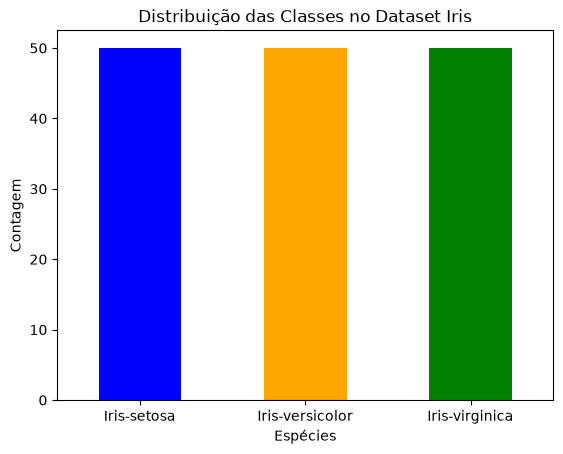

In [5]:
df["Species"].value_counts().plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title("Distribuição das Classes no Dataset Iris")
plt.xlabel("Espécies")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Divisão entre treino e teste, mantendo a proporção das três espécies
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# A árvore usa entropia e profundidade limitada para reduzir overfitting
tree_model = DecisionTreeClassifier(criterion="gini", min_samples_split=2, random_state=42)
tree_model.fit(X_train, y_train)

# Predição e avaliação
y_pred = tree_model.predict(X_test)

print("Acurácia no teste:", accuracy_score(y_test, y_pred))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))


Acurácia no teste: 1.0

Relatório de classificação:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Matriz de confusão:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


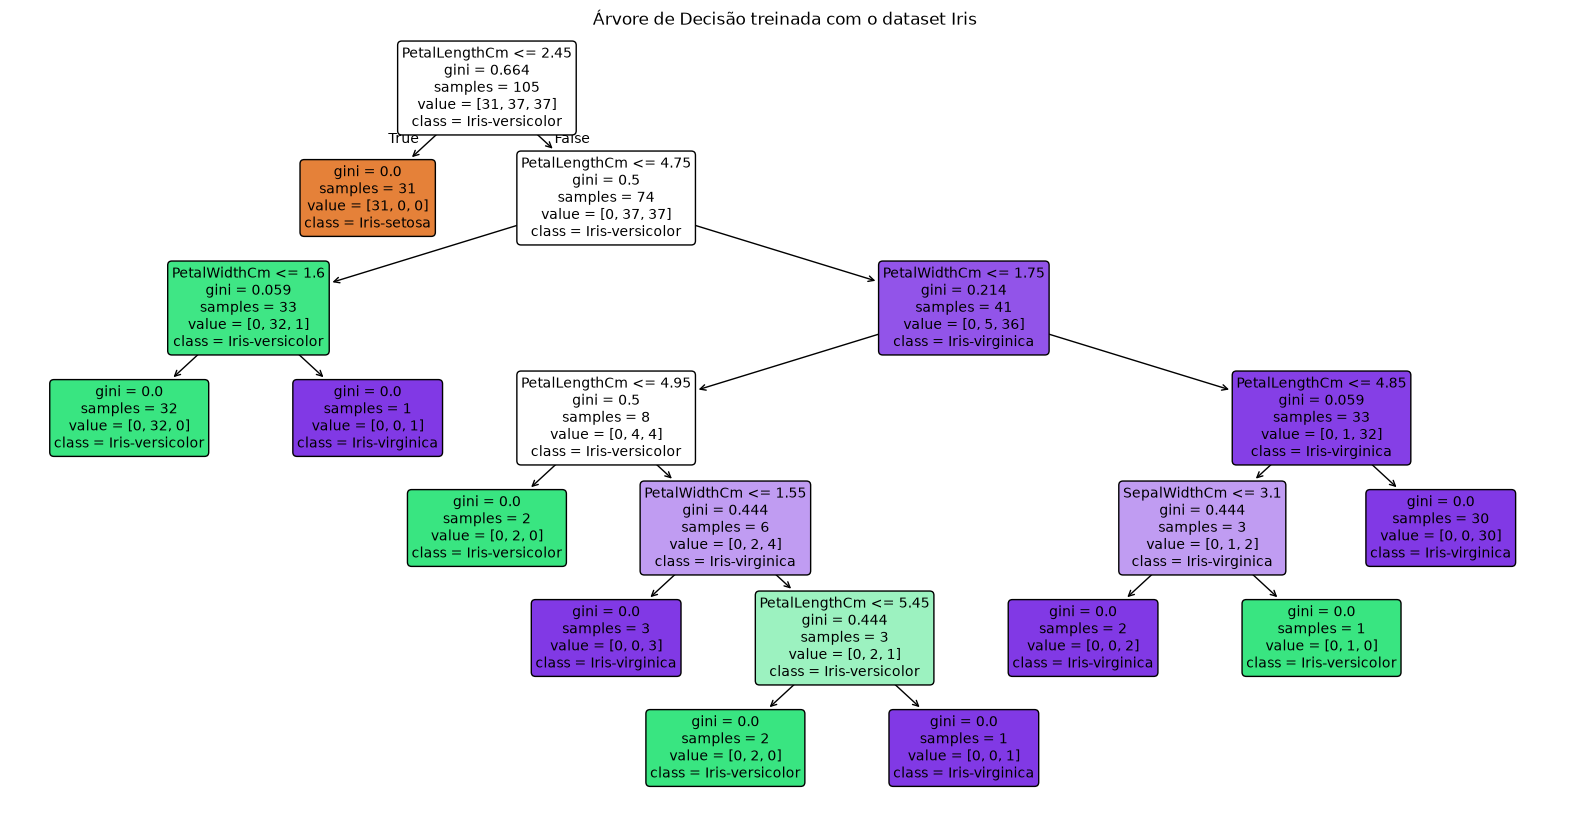

In [7]:
# Visualizando a árvore treinada
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=feature_columns, class_names=target_names, filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão treinada com o dataset Iris")
plt.show()

## 11. Exemplo prático simples construído do zero (*From Scratch*)

Para consolidar a teoria matemática, abaixo temos uma implementação do algoritmo para a construção de uma árvore de decisão utilizando programação orientada a objetos e chamadas recursivas. O modelo constrói os nós calculando o **Índice de Gini** e procurando a variável que entrega a melhor redução do Índice de Gini (que também pode ser entendido como um Ganho de Informação) na partição.

Cada nó armazena a regra de divisão (`feature` e `threshold`), o ganho de informação e referências para os nós filhos. Quando `value` é preenchido, o nó é uma folha e representa a classe prevista.

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from pathlib import Path

In [9]:
data_path = Path("../data/iris.csv")

df = pd.read_csv(data_path)

In [10]:
X = df.drop(columns=['Id', "Species"]).values
y = df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

In [11]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # Se for um nó interno / nó de decisão, feature_idx e threshold serão usados para dividir os dados
        self.feature_idx = feature_idx # índice da feature que será usada para dividir os dados
        self.threshold = threshold # valor de corte da feature que será usado para dividir os dados
        self.info_gain = info_gain # quantidade de informação ganha ao dividir os dados nesse nó
        self.left = left # nó filho à esquerda
        self.right = right # nó filho à direita

        # Se for um nó folha, value será usado para armazenar a classe que será predita
        self.value = value # classe que será predita se for um nó folha

In [12]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=None):
        self.min_samples_split = min_samples_split # número mínimo de amostras que um nó deve ter para ser dividido
        self.max_depth = max_depth # a profundidade máxima da árvore de decisão

    def build_tree(self, dataset, curr_depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        if n_samples >= self.min_samples_split and (self.max_depth is None or curr_depth <= self.max_depth):
            best_split = self.get_best_split(dataset, n_features)

            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_dataset"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)

        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    def get_best_split(self, dataset, n_features):
        best_split = {"feature_idx": None, "threshold": None, "info_gain": -1, "left_dataset": None, "right_dataset": None}

        for feature_idx in range(n_features):
            feature_values = dataset[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split(dataset, feature_idx, threshold)

                if len(left_dataset) > 0 and len(right_dataset) > 0:
                    parent_y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]

                    info_gain = self.information_gain(parent_y, left_y, right_y)

                    if info_gain > best_split["info_gain"]:
                        best_split["feature_idx"] = feature_idx
                        best_split["threshold"] = threshold
                        best_split["info_gain"] = info_gain
                        best_split["left_dataset"] = left_dataset
                        best_split["right_dataset"] = right_dataset

        return best_split

    def split(self, dataset, feature_idx, threshold):
        left_dataset = np.array([row for row in dataset if row[feature_idx] <= threshold])
        right_dataset = np.array([row for row in dataset if row[feature_idx] > threshold])

        return left_dataset, right_dataset

    def information_gain(self, parent_y, left_y, right_y):
        left_weight = len(left_y) / len(parent_y)
        right_weight = len(right_y) / len(parent_y)

        information_gain = self.gini(parent_y) - (left_weight * self.gini(left_y) + right_weight * self.gini(right_y))

        return information_gain

    def gini(self, y): # quanto maior o valor, mais impuro é o nó. O valor máximo é 0.5, que ocorre quando as classes estão igualmente distribuídas. O valor mínimo é 0, que ocorre quando todas as amostras pertencem à mesma classe.
        class_counts = Counter(y)
        impurity = 1.0 - sum((count / len(y)) ** 2 for count in class_counts.values())
        return impurity 

    def fit(self, X, y):
        dataset = np.concatenate((X, y.reshape(-1, 1)), axis=1)
        self.root = self.build_tree(dataset)

    def predict(self, X):
        predictions = [self.__predict(row, self.root) for row in X]
        return predictions

    def __predict(self, row, node):
        if node.value is not None: # se for um nó folha, retorna a classe que será predita
            return node.value

        # Se for um nó interno, verifica se o valor da feature é menor ou igual ao threshold para decidir se vai para o nó filho à esquerda ou à direita, recursivamente até chegar em um nó folha e retornar a classe que será predita
        feature_value = row[node.feature_idx]
        if feature_value <= node.threshold:
            return self.__predict(row, node.left)
        else:
            return self.__predict(row, node.right)

In [13]:
dt = DecisionTree(min_samples_split=2)
dt.fit(X_train, y_train)

predictions = dt.predict(X_test)

accuracy = np.mean(predictions == y_test) * 100
print(f"Acurácia no teste: {accuracy:.2f}%")

Acurácia no teste: 95.56%


## 12. Conclusão

Neste notebook, foram estudados os fundamentos teóricos das **Árvores de Decisão**, incluindo sua estrutura em nós, ramos e folhas, o processo de divisão recursiva e os critérios de impureza, como Índice Gini, Entropia, Erro Quadrático Médio e Ganho de Informação. Também foi demonstrada a aplicação do modelo ao dataset Iris, desde a preparação dos dados até o treinamento, avaliação e visualização da árvore. Por fim, a implementação do algoritmo do zero permitiu compreender, na prática, como os melhores cortes são selecionados e como as previsões são realizadas. Os resultados reforçam a versatilidade e a interpretabilidade do modelo, destacando a importância do controle de sua complexidade para evitar overfitting.